# Genetic Optimization (GO)

## Overview

![Overview](../figures/go_overview.png)

GO is a population-based heuristic. Each generation:
1. **Select** two parents from the population (rank-based, biased toward better solutions)
2. **Crossover** — combine their genes to form a child
3. **Mutate** — apply a small perturbation to the child
4. **Select survivors** from the working population to form the next generation

Key parameters: population size $N$, working population size $M > N$, selection temperatures $T_{sel1}$ (parent selection) and $T_{sel2}$ (survivor selection).

In [1]:
# Import path to source directory (bit of a hack in Jupyter)
import sys
import os
pwd = %pwd
sys.path.append(os.path.join(pwd, '..', 'src'))

%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import pandas as pd
from tqdm.notebook import tqdm

import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

from heur_go import GeneticOptimization, Crossover, UniformMultipoint, RandomCombination
from heur_aux import CauchyMutation, MirrorCorrection
from objfun_rastrigin import Rastrigin

## Building blocks

### 1. Selection

Parents and survivors are chosen by **rank-based selection** using an exponential distribution.
Given a sorted population (best first) and selection temperature $T$:

$$R = \left\lceil \frac{-T \ln U}{1} \right\rceil$$

where $U \sim \text{Uniform}(0, 1)$ and $R$ is the (1-based) rank of the selected individual.

Low $T$ → nearly always picks rank 1 (greedy). High $T$ → flat distribution (random).

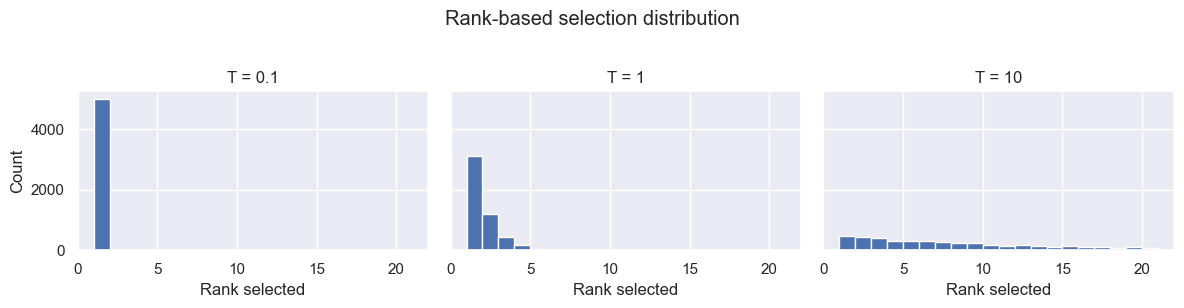

In [3]:
rng_demo = np.random.default_rng(42)
u = rng_demo.uniform(size=5000)

fig, axes = plt.subplots(1, 3, figsize=(12, 3), sharey=True)
for ax, T in zip(axes, [0.1, 1, 10]):
    ranks = np.ceil(-T * np.log(u))
    ax.hist(ranks[ranks <= 20], bins=range(1, 22), edgecolor='white')
    ax.set_title(f'T = {T}')
    ax.set_xlabel('Rank selected')
axes[0].set_ylabel('Count')
plt.suptitle('Rank-based selection distribution', y=1.02)
plt.tight_layout()

### 2. Crossover

Three operators are available. Given parents `x` (all 0s) and `y` (all 9s) for illustration:

In [4]:
rng_demo = np.random.default_rng(0)
x = np.zeros(10, dtype=int)
y = 9 * np.ones(10, dtype=int)

print('Parents:              x =', x)
print('                      y =', y)
print()
print('Crossover (random mix):    ', Crossover().crossover(x, y, rng_demo))
print('UniformMultipoint(4):      ', UniformMultipoint(4).crossover(x, y, rng_demo))
print('RandomCombination:         ', RandomCombination().crossover(x, y, rng_demo))

Parents:              x = [0 0 0 0 0 0 0 0 0 0]
                      y = [9 9 9 9 9 9 9 9 9 9]

Crossover (random mix):     [9 0 0 0 9 9 9 9 9 9]
UniformMultipoint(4):       [0 0 9 9 0 0 9 9 0 0]
RandomCombination:          [2 8 6 0 3 8 5 0 7 7]


- **`Crossover`** (random mix): each gene independently drawn from one parent at random.
- **`UniformMultipoint(n)`**: alternating blocks of length $\lceil d/n \rceil$ taken from each parent.
- **`RandomCombination`**: each gene is a random value *between* the two parents — the only operator that can produce values not present in either parent. Most natural for continuous domains.

### 3. Mutation

We reuse `CauchyMutation` from the FSA toolbox. In the GO context it plays a secondary role — crossover handles global recombination, mutation adds local diversity. The mutation width `r` should therefore be smaller than in FSA.

## Objective function: Rastrigin (2D)

$$f(x_1, x_2) = 20 + x_1^2 + x_2^2 - 10(\cos 2\pi x_1 + \cos 2\pi x_2)$$

Global minimum $f^* = 0$ at $(0, 0)$. The landscape has a regular grid of local minima at integer coordinates — a direct test of the algorithm's ability to escape traps.

In [5]:
of = Rastrigin(n=5, eps=0.5)
print(f'Domain : [{of.a[0]}, {of.b[0]}]^2')
print(f'f*     : {of.fstar}  (success = f(x) ≤ {of.fstar})')
print()
print('Note: the nearest local minima have f≈1, so eps=0.5 means')
print('the algorithm must reach the global basin, not just any local minimum.')

Domain : [-5.12, 5.12]^2
f*     : 0.5  (success = f(x) ≤ 0.5)

Note: the nearest local minima have f≈1, so eps=0.5 means
the algorithm must reach the global basin, not just any local minimum.


### Experiment setup

Unified experiment runner and stats computer, consistent with the FSA scaling notebook.

In [6]:
def experiment_go(of, maxeval, num_runs, N, M, Tsel1, Tsel2, mutation, crossover, label):
    results = []
    for i in tqdm(range(num_runs), desc=f'Testing {label}'):
        result = GeneticOptimization(
            of, maxeval, N=N, M=M, Tsel1=Tsel1, Tsel2=Tsel2,
            mutation=mutation, crossover=crossover, seed=i
        ).search()
        result['run'] = i
        result['heur'] = label
        results.append(result)
    return pd.DataFrame(results, columns=['heur', 'run', 'best_x', 'best_y', 'neval', 'success'])


def compute_stats(table, group_by='heur'):
    def agg(g):
        rel = g['success'].mean()
        successful = g.loc[g['success'], 'neval']
        mne = successful.mean() if len(successful) > 0 else np.nan
        feo = mne / rel if (rel > 0 and not np.isnan(mne)) else np.nan
        return pd.Series({'rel': rel, 'mne': mne, 'feo': feo})
    return table.groupby(group_by)[['neval', 'success']].apply(agg).reset_index()


NUM_RUNS = 500
MAXEVAL  = 10_000

## Parameter sweep: population size $N$

Using `RandomCombination` (most natural for continuous domains) and $M = 3N$.
Varying $N$ from 1 (effectively a single-solution hill-climber) to 50.

In [7]:
table_N = pd.DataFrame()

for N in [10, 20, 50, 100, 500]:
    res = experiment_go(
        of=of, maxeval=MAXEVAL, num_runs=NUM_RUNS,
        N=N, M=N * 3, Tsel1=1.0, Tsel2=0.1,
        mutation=CauchyMutation(r=0.01, correction=MirrorCorrection(of)),
        crossover=RandomCombination(),
        label=f'GO_N{N}'
    )
    res['N'] = N
    table_N = pd.concat([table_N, res], ignore_index=True)

Testing GO_N10:   0%|          | 0/500 [00:00<?, ?it/s]

Testing GO_N20:   0%|          | 0/500 [00:00<?, ?it/s]

Testing GO_N50:   0%|          | 0/500 [00:00<?, ?it/s]

Testing GO_N100:   0%|          | 0/500 [00:00<?, ?it/s]

Testing GO_N500:   0%|          | 0/500 [00:00<?, ?it/s]

  N    heur   rel         mne          feo
 10  GO_N10 0.466 6274.476395 13464.541620
 20  GO_N20 0.622 6185.064309  9943.833294
 50  GO_N50 0.726 6048.732782  8331.587855
100 GO_N100 0.648 6195.719136  9561.294963
500 GO_N500 0.306 7595.954248 24823.379897


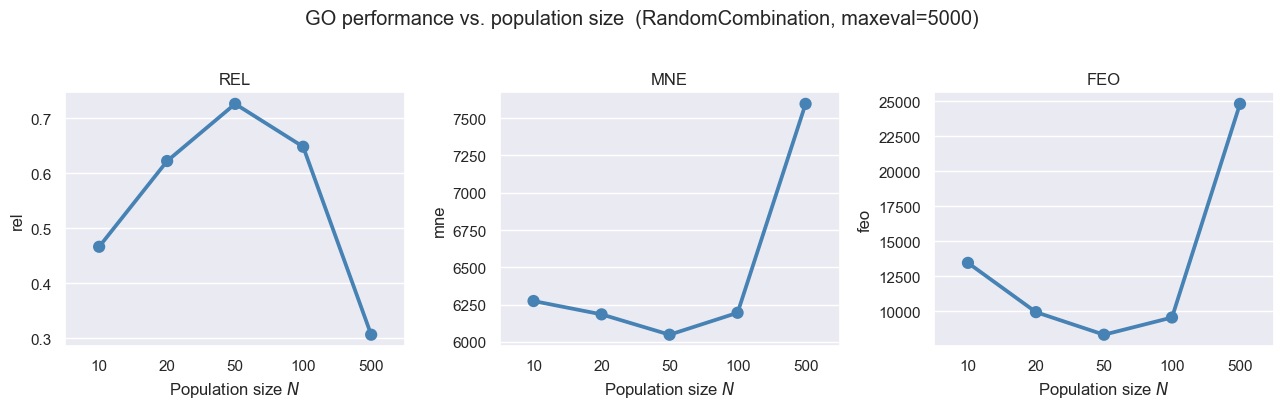

In [8]:
stats_N = compute_stats(table_N, group_by=['N', 'heur'])
print(stats_N.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, metric in zip(axes, ['rel', 'mne', 'feo']):
    sns.pointplot(data=stats_N, x='N', y=metric, ax=ax, color='steelblue')
    ax.set_title(metric.upper())
    ax.set_xlabel('Population size $N$')
plt.suptitle('GO performance vs. population size  (RandomCombination, maxeval=5000)', y=1.02)
plt.tight_layout()

$N=50$ is the sweet spot: highest reliability (REL = 0.726) and lowest FEO (≈ 8 332).
Below that, diversity is too low; above it, the budget is spread too thin across too many individuals.

## Parameter sweep: crossover operator

Fixing $N$ at the sweet spot found above and comparing all four crossover operators.

In [11]:
BEST_N = 50

crossovers = [
    ('mix',  Crossover()),
    ('uni1', UniformMultipoint(1)),
    ('uni2', UniformMultipoint(2)),
    ('rnd',  RandomCombination()),
]

table_co = pd.DataFrame()

for co_name, co in crossovers:
    res = experiment_go(
        of=of, maxeval=MAXEVAL, num_runs=NUM_RUNS,
        N=BEST_N, M=BEST_N * 3, Tsel1=1.0, Tsel2=0.1,
        mutation=CauchyMutation(r=0.01, correction=MirrorCorrection(of)),
        crossover=co,
        label=f'GO_{co_name}'
    )
    table_co = pd.concat([table_co, res], ignore_index=True)

Testing GO_mix:   0%|          | 0/500 [00:00<?, ?it/s]

Testing GO_uni1:   0%|          | 0/500 [00:00<?, ?it/s]

Testing GO_uni2:   0%|          | 0/500 [00:00<?, ?it/s]

Testing GO_rnd:   0%|          | 0/500 [00:00<?, ?it/s]

In [12]:
stats_co = compute_stats(table_co)
stats_co

,heur,rel,mne,feo
0,GO_mix,0.742,5922.005391,7981.139341
1,GO_rnd,0.726,6048.732782,8331.587855
2,GO_uni1,0.648,6298.234568,9719.497790
3,GO_uni2,0.684,6168.684211,9018.544167


## Conclusion

### Context: where FSA left off

On Rastrigin $n=5$ (budget 10 000 evals, 500 runs), the best FSA variant (`FSA_precision_scaled`) achieved **REL = 0.018**.
Every other FSA configuration failed completely. Single-trajectory search simply cannot escape the dense grid of local minima as dimensionality grows.

### Population size

The sweep over $N \in \{10, 20, 50, 100, 500\}$ shows a clear optimum at **$N = 50$** (REL = 0.726, FEO ≈ 8 332).

| $N$ | REL | FEO |
|-----|-----|-----|
| 10 | 0.466 | 13 465 |
| 20 | 0.622 | 9 944 |
| **50** | **0.726** | **8 332** |
| 100 | 0.648 | 9 561 |
| 500 | 0.306 | 24 823 |

Small $N$ gives insufficient diversity — GO degenerates toward a restartable hill-climber.
Very large $N$ exhausts the evaluation budget within too few generations, preventing convergence.

### Crossover operator

Fixing $N = 50$, all operators are compared on Rastrigin $n=5$:

| Operator | REL | FEO |
|----------|-----|-----|
| `Crossover` (random mix) | **0.742** | 7 981 |
| `RandomCombination`       | 0.726 | 8 332 |
| `UniformMultipoint(2)`    | 0.684 | 9 019 |
| `UniformMultipoint(1)`    | 0.648 | 9 720 |

**Random mix** performs best: each gene is independently drawn from one of the two parents, giving maximum recombination diversity.
`RandomCombination` (interpolation between parents) is a close second but can land between local minima rather than at one of them.
Block-based `UniformMultipoint` operators lag behind — preserving large contiguous segments is less useful on a landscape where the optimal genes are spatially independent.

### GO vs. FSA on Rastrigin $n=5$

| Method | Best REL |
|--------|----------|
| FSA (best config) | 0.018 |
| GO (best config)  | **0.742** |

Population-based search via crossover achieves a **40× improvement in reliability** over the best FSA configuration on the same landscape and budget.
Crossover lets the population collectively triangulate toward the global basin, while mutation provides the fine-grained local search that FSA used to handle alone.

### Assignment

* How does GO scale with dimension? Repeat the experiments on `Rastrigin(n=10)` — does the sweet spot for $N$ shift, and can GO succeed where FSA failed completely?
* Try `MirrorCorrection` vs `ExtensionCorrection` for mutation — does the boundary-handling strategy affect performance on this domain?